# Cancer Diagnosis with Machine Learning
## Wisconsin Breast Cancer Dataset

This notebook explores the Wisconsin Breast Cancer Dataset (UCI/sklearn) 
with the goal of classifying tumors as malignant or benign based on cell 
nucleus measurements.

### Dataset
- 569 samples (357 benign, 212 malignant)
- 30 features: 10 unique cell measurements computed as mean, standard error, and worst value
- Binary classification: malignant (0) vs benign (1)

### Notebook Structure
1. Exploratory Data Analysis (EDA)
2. Preprocessing & Pipeline
3. Model Training & Comparison
4. Model Evaluation & Feature Analysis

### Note on Evaluation Metrics
In medical diagnostics, recall (sensitivity) is prioritized over accuracy while
missing a cancer case is worse than a false alarm.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(df.shape)
print(df.head())


(569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0   

## 1. Class Distribution
Checking the balance between malignant and benign cases. 
Note: target = 0 is malignant, target = 1 is benign (verified via data.target_names).

In [5]:
# Check class balance
print(data.target_names)
print(data.target_names[0])
print(data.target_names[1])
print(df['target'].value_counts())

['malignant' 'benign']
malignant
benign
target
1    357
0    212
Name: count, dtype: int64


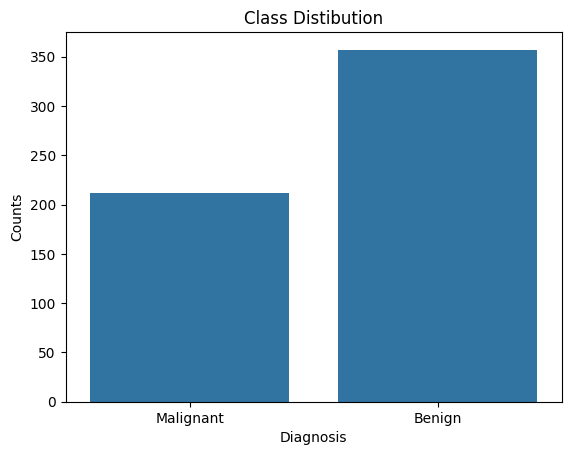

In [7]:
sns.countplot(x='target', data=df)
plt.xticks([0, 1], ['Malignant', 'Benign'])
plt.title('Class Distibution')
plt.xlabel('Diagnosis')
plt.ylabel('Counts')
plt.show()

## 2. Feature Distributions
Plotting histograms for all 30 features. Most features show right-skewed 
distributions, which is common in biomedical measurements.

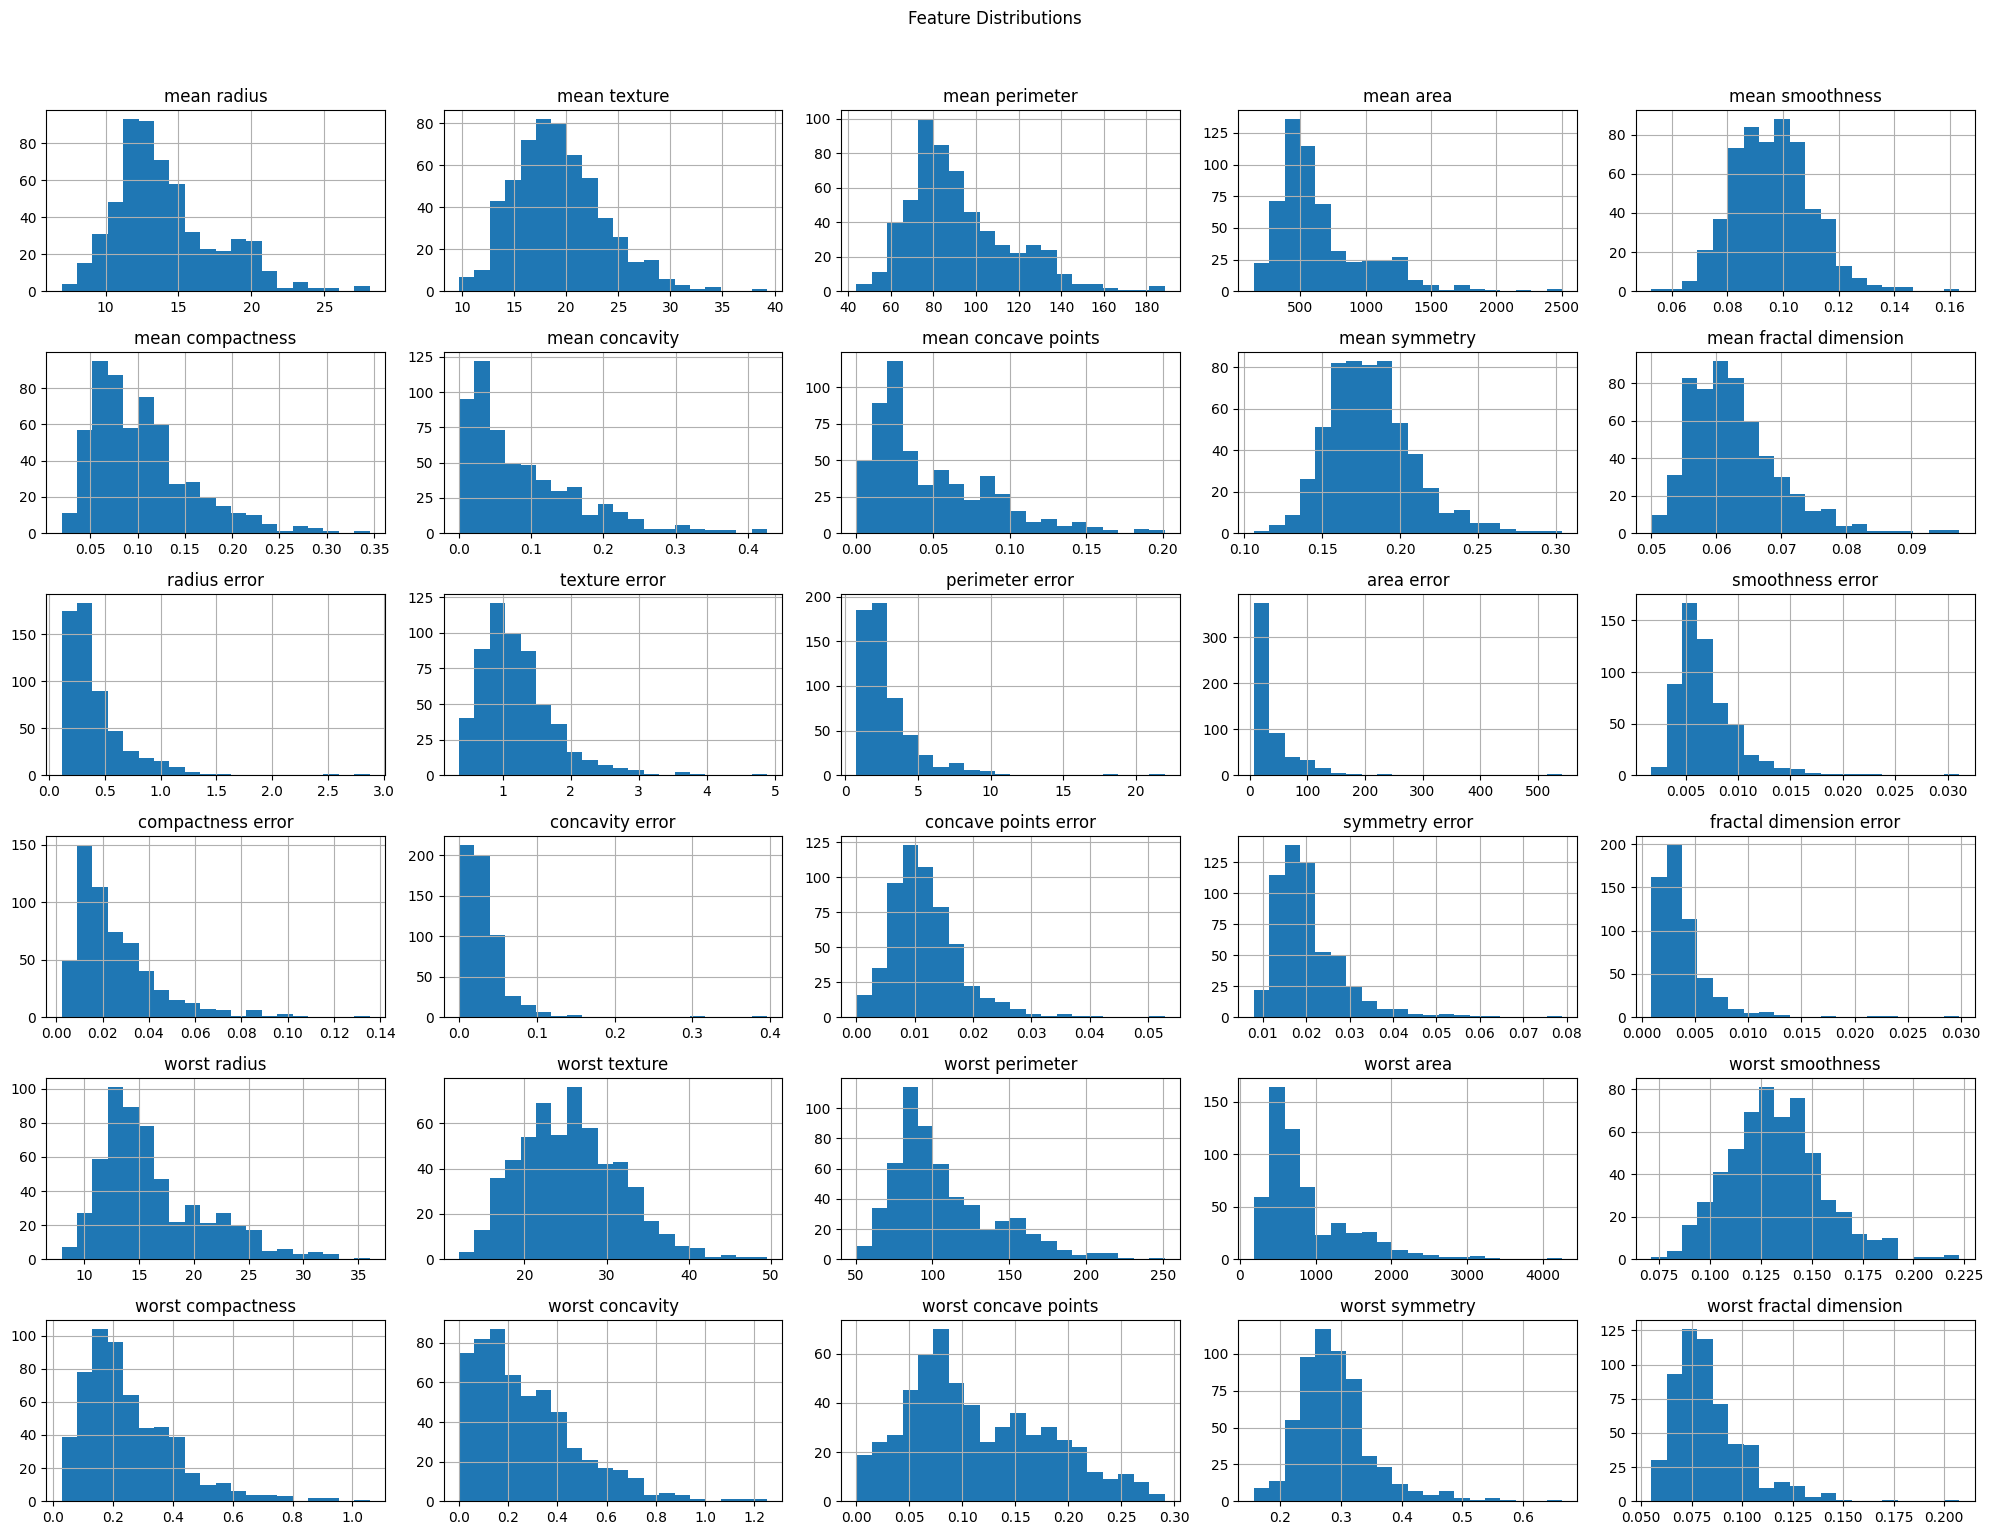

In [8]:
# Plot histogram for all features
df.drop('target', axis=1).hist(figsize= (20, 15), bins=20)
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

## 3. Correlation Matrix
Heatmap showing correlations between all features. Strong positive correlations 
(red) are expected since features are grouped as triplets — mean, standard error, 
and worst value of the same underlying measurement.

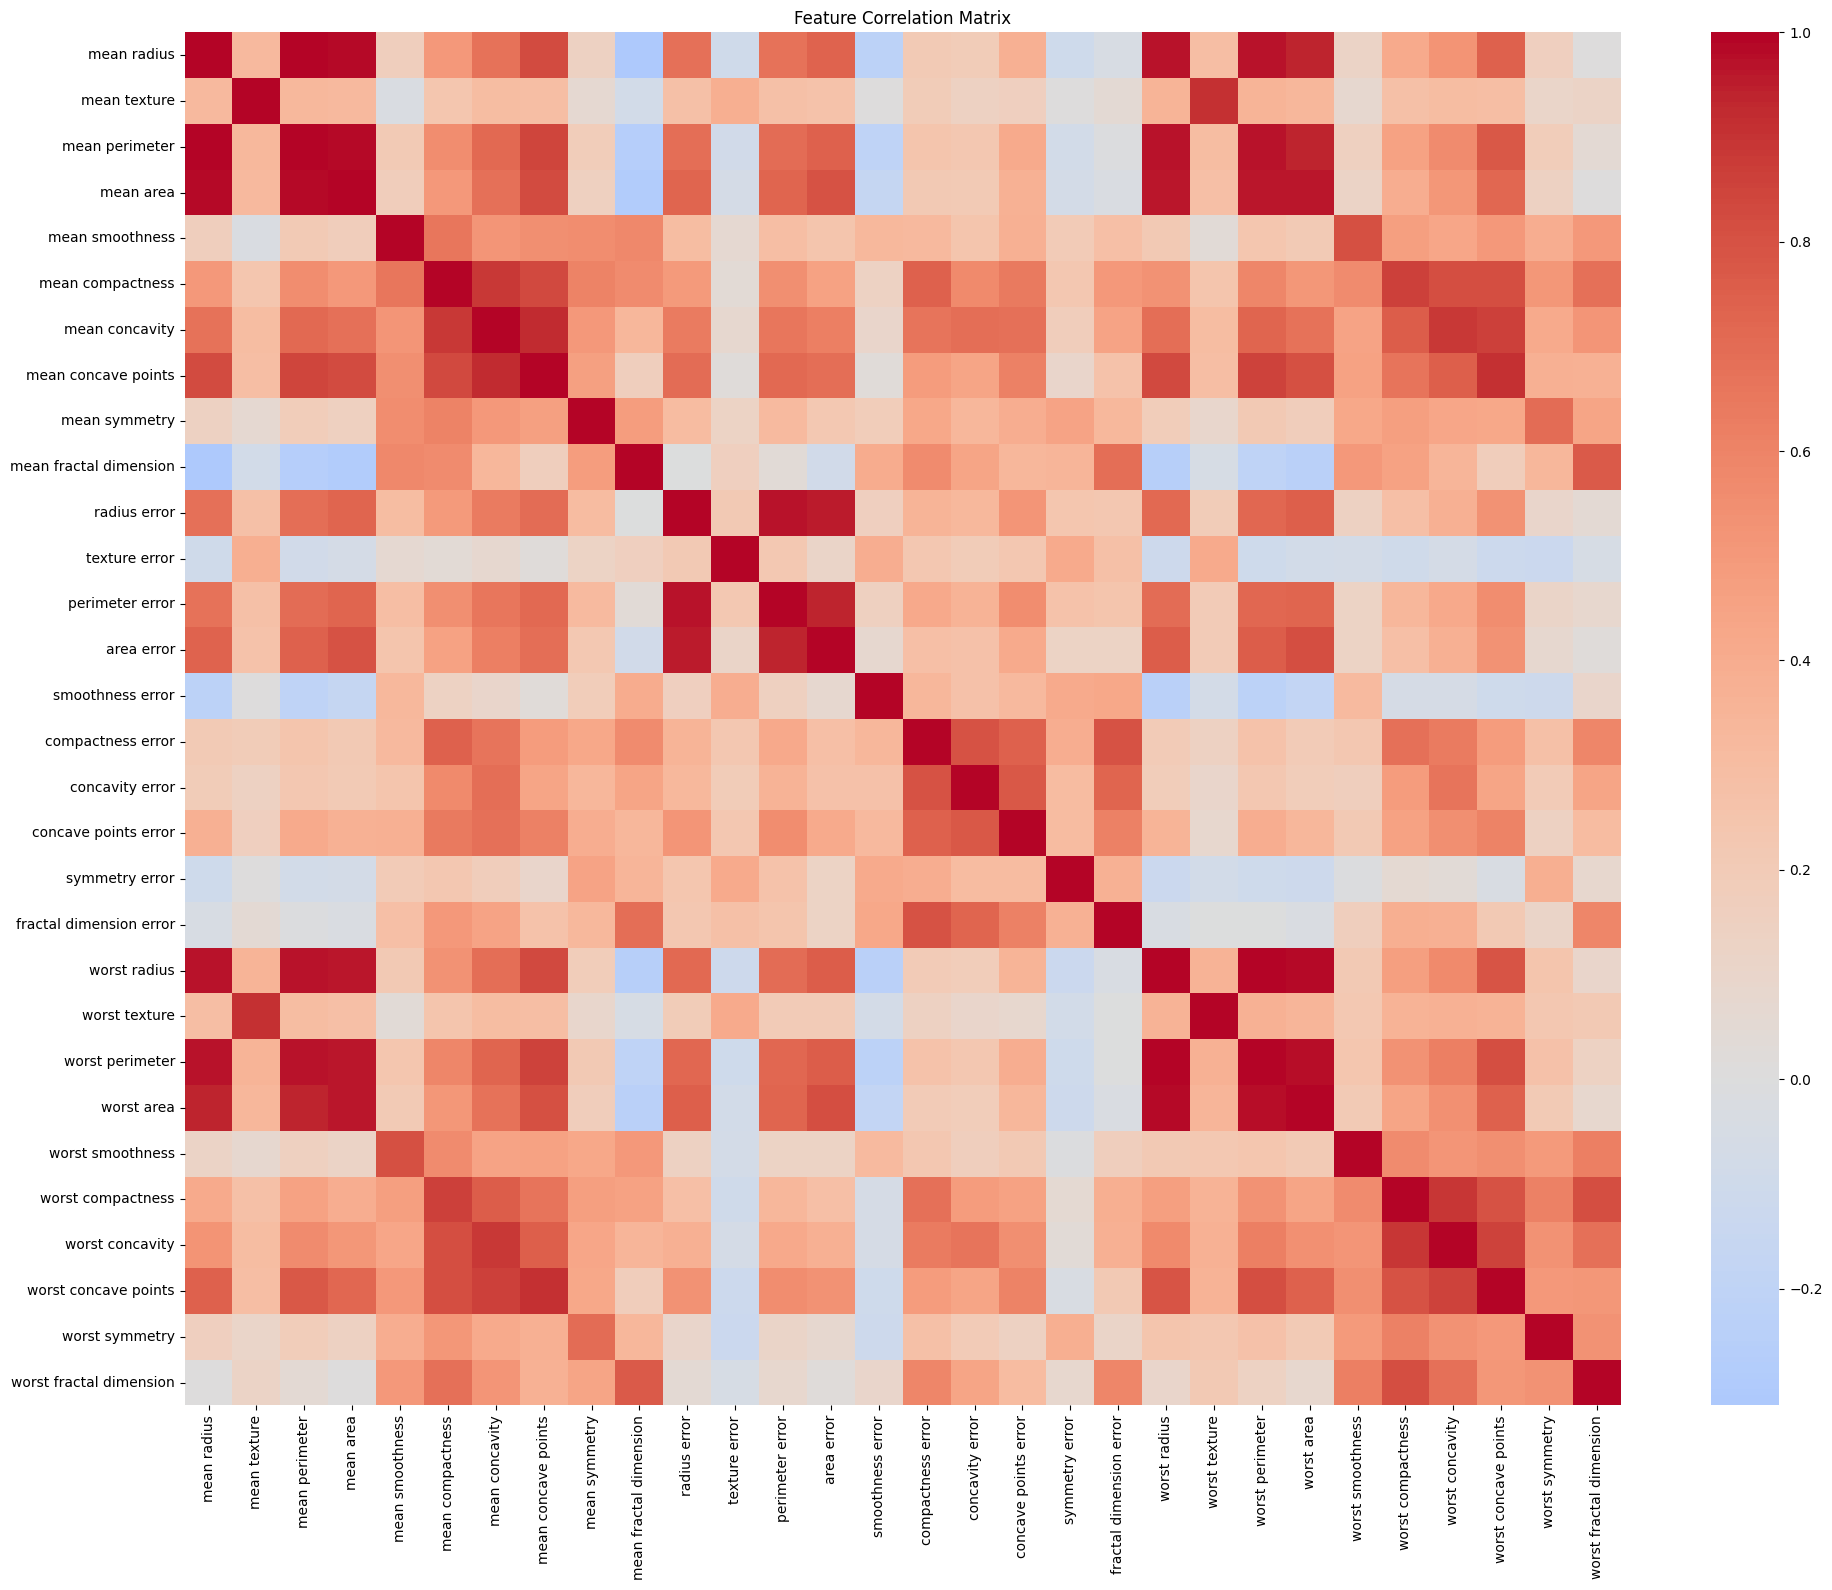

In [10]:
# Correlation matrix
plt.figure(figsize=(20, 16))
sns.heatmap(df.drop('target', axis=1).corr(),
            annot=False,
            cmap='coolwarm',
            center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 4. Feature-Target Correlation
Correlation of each feature with the target variable. Negative correlation 
indicates association with malignancy (target=0), positive with benign (target=1).

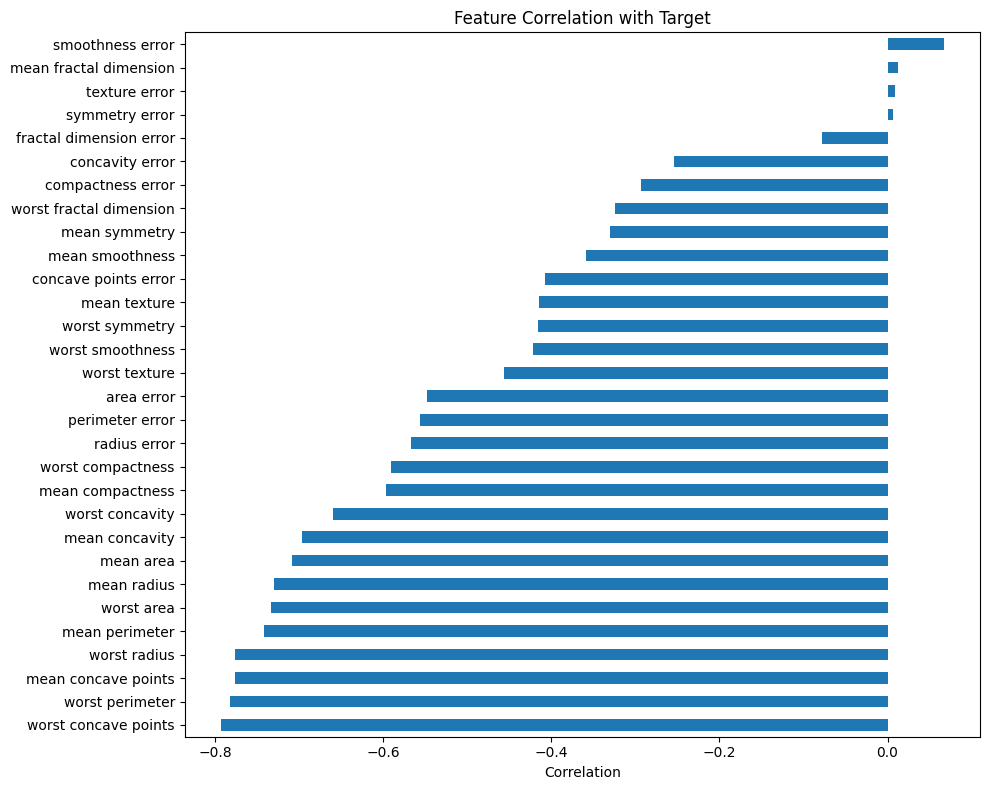

In [12]:
# Correlation against target
target_corr = df.corr()['target'].drop('target').sort_values()
plt.figure(figsize=(10, 8))
target_corr.plot(kind='barh')
plt.title('Feature Correlation with Target')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

### Key Findings
- Strongest indicators of malignancy: worst concave points, worst perimeter, mean concave points
- "Worst" features dominate — extreme cell measurements are more diagnostically useful than averages
- Error features show weak correlation, suggesting high measurement noise